# 03 合成数据识别

**要回答的问题**：这份数据是真实观测来的，还是程序随机生成的？

**为什么这个问题重要**：如果数据是合成的，那么无论用什么方法，都不可能从中提炼出
真实世界的业务规律。在此之上的任何"洞察"都是幻觉。

**方法**：先用箱线图、散点图做常规探索（作为对照），再用三条硬证据判定：
均匀随机性、取值范围整齐性、原因字段独立性。


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 让 notebooks/ 下的代码能 import 到项目根的 src/ 包
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA = PROJECT_ROOT / 'data' / 'raw' / 'smart_logistics_dataset.csv'
df = pd.read_csv(DATA, keep_default_na=False, na_values=[''])
df['Logistics_Delay'] = df['Logistics_Delay'].astype('category')
total_shipments = len(df)
print(f'{total_shipments} 行 × {df.shape[1]} 列')


1000 行 × 16 列


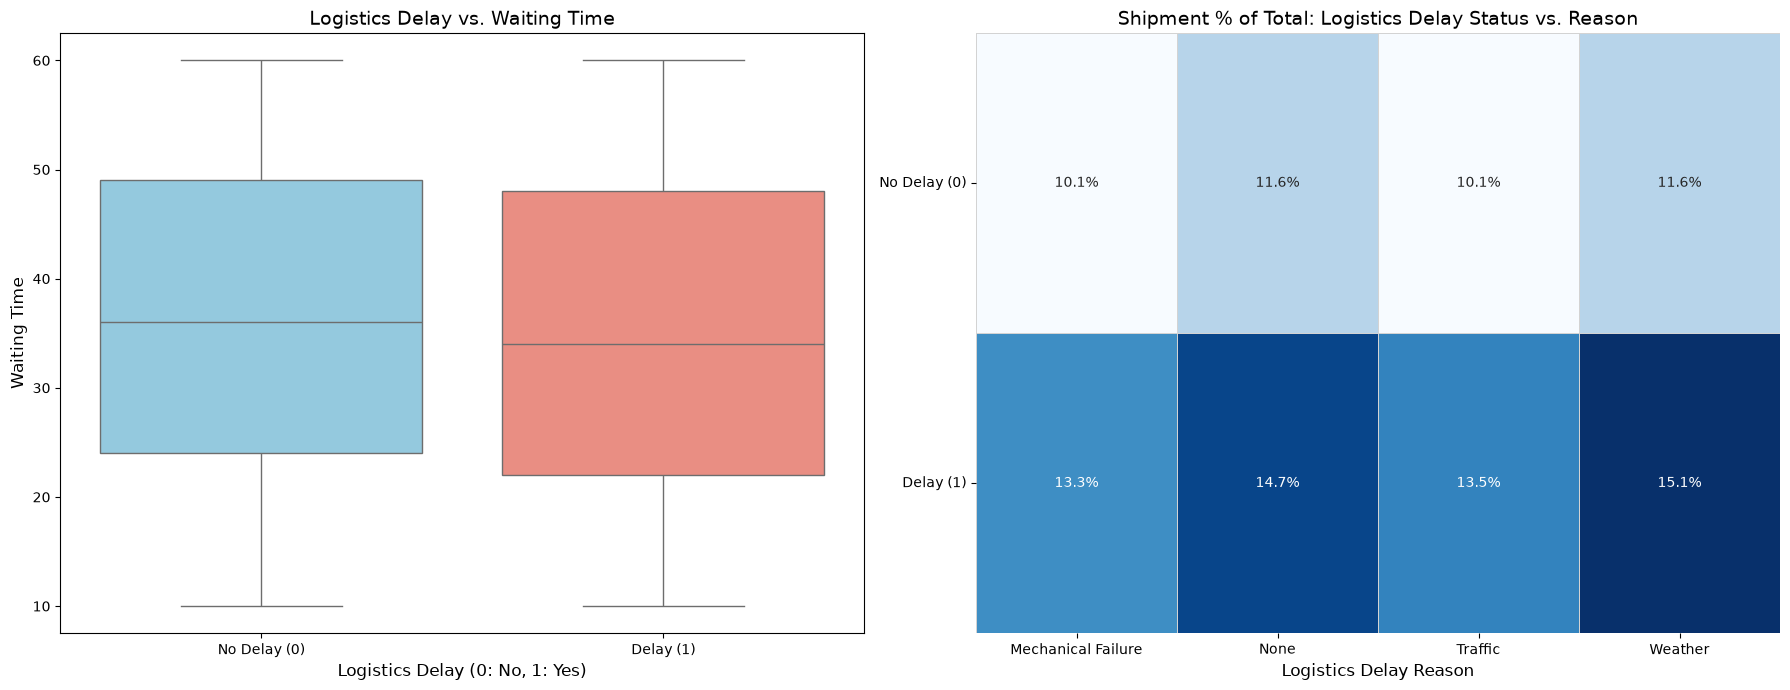

In [2]:
fig,axes=plt.subplots(1,2,figsize=(18,7))#创建 1 行 2 列 的子图布局,整体尺寸宽18，高7。
#fig 和 axes 对象分别代表整个图形和其中的一个子图。
plt.style.use('ggplot')#图形的整体风格为 ggplot 风格

#画左边的箱线图,比较“无延迟”和“有延迟”两种情况下的“等待时间”分布
sns.boxplot(
    x='Logistics_Delay',
    y='Waiting_Time',
    data=df,
    palette=['skyblue','salmon'],#给两个箱体指定颜色
    ax=axes[0]#把图画在第一个子图上。
)
axes[0].set_xticklabels(['No Delay (0)', 'Delay (1)'])#设置横轴刻度标签为 “No Delay (0)”  “Delay (1)”。
axes[0].set_title('Logistics Delay vs. Waiting Time', fontsize=14)#设置图标题
axes[0].set_xlabel('Logistics Delay (0: No, 1: Yes)', fontsize=12)#设置横轴名称
axes[0].set_ylabel('Waiting Time', fontsize=12)#设置纵轴名称
#fontsize字体大小

contingency_table = pd.crosstab(df['Logistics_Delay'],df['Logistics_Delay_Reason'])
#偶发事件表。crosstab生成频数表[行索引，列索引]。
contingency_table.head()
percentage_table = (contingency_table / total_shipments) * 100

annot_labels=percentage_table.map(lambda x: f'{x:.1f}%')
#map() 函数用于将一个函数应用于一个或多个可迭代对象（如列表、元组等）的每个元素，并返回一个包含结果的迭代器。
# 匿名函数（lambda 函数），作用是把输入的数字 x 转换成一个字符串。
#map(lambda x: f'{x:.1f}%'),把一组数字中的每一个都转换成一个保留一位小数的百分比字符串。

#热力图
sns.heatmap(
    percentage_table,#要绘制的数据表格
    annot=annot_labels,#annot 参数用来在热力图的每个单元格中显示文字注释。
    fmt='s',#fmt 参数告诉函数如何格式化注释文字。s是字符串（string）
    cmap='Blues',#设置颜色
    linewidths=0.5,#设置热力图中每个单元格之间的分隔线宽度
    linecolor='lightgrey',#设置分隔线的颜色为浅灰色
    cbar=False,#是否显示颜色条
)

axes[1].set_yticklabels(['No Delay (0)', 'Delay (1)'], rotation=0)
#把 y 轴上的数字“0”和“1”换成文字“无延迟(0)”和“延迟(1)”，文字水平显示（不旋转）
axes[1].set_title('Shipment % of Total: Logistics Delay Status vs. Reason', fontsize=14)#设置标题
axes[1].set_xlabel('Logistics Delay Reason', fontsize=12)#设置X轴名称
axes[1].set_ylabel('')#设置y轴

plt.tight_layout()#tight_layout()会自动调整子图之间的间距
plt.show()

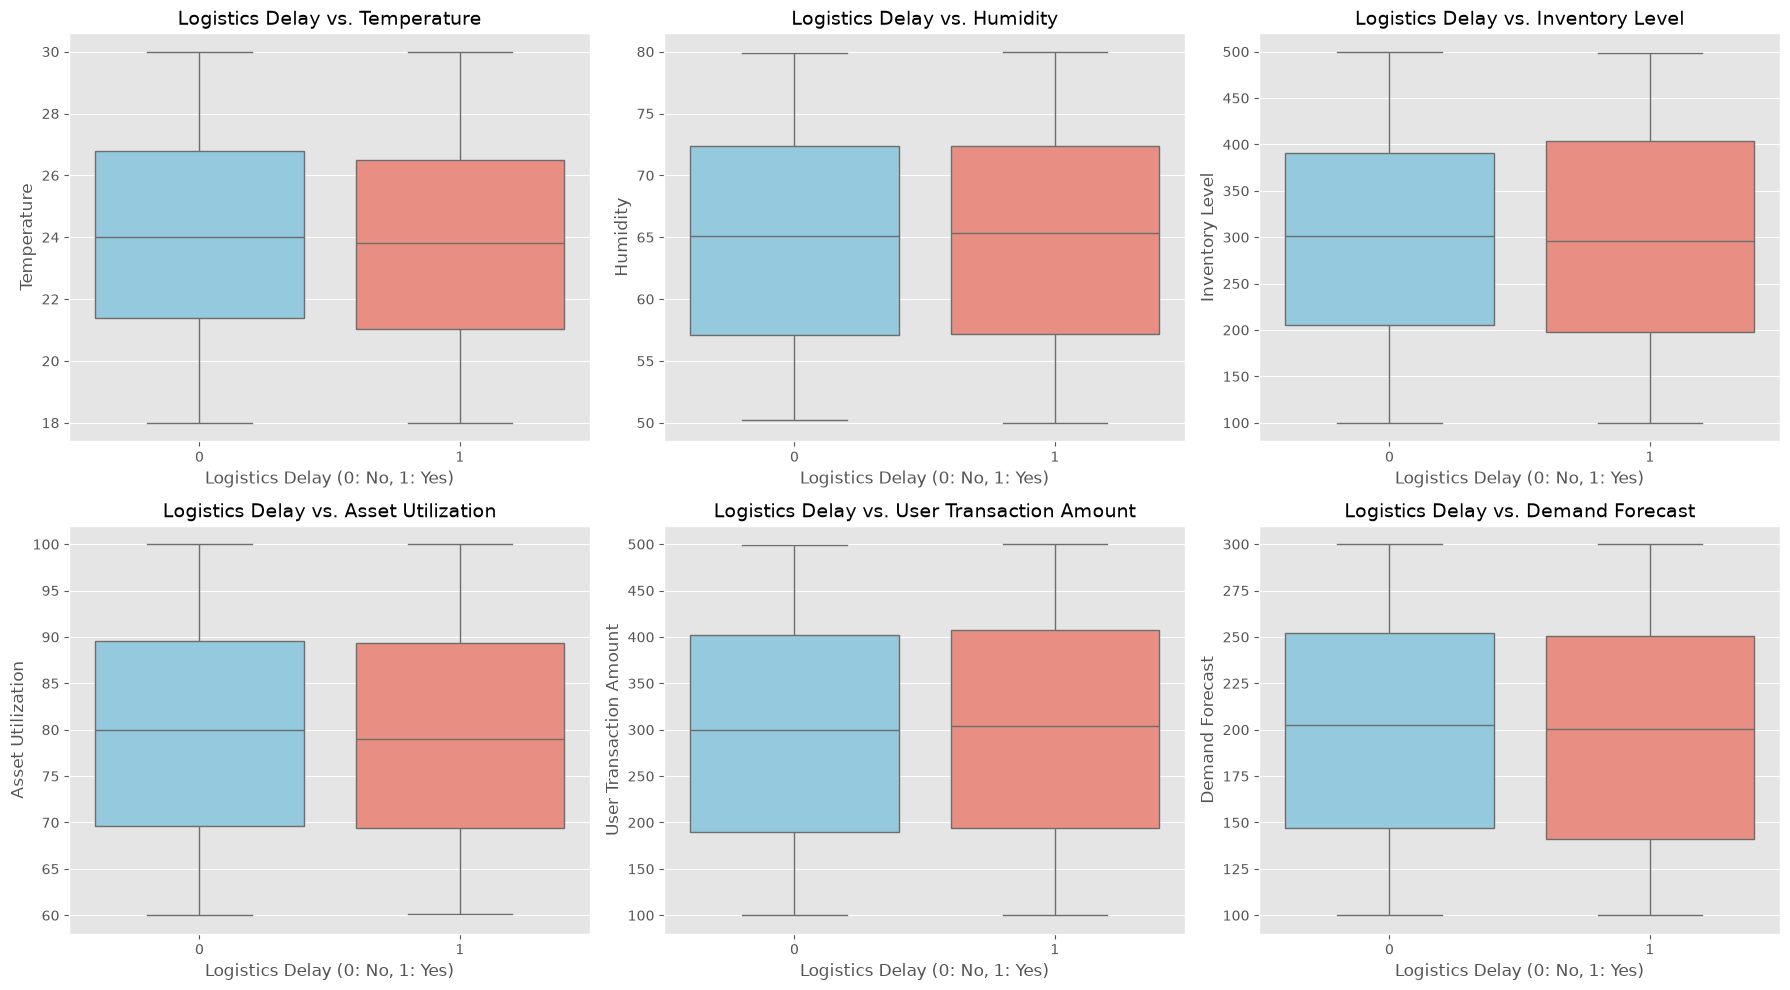

In [3]:
numerical_features = [
    'Temperature',
    'Humidity',
    'Inventory_Level',
    'Asset_Utilization',
    'User_Transaction_Amount',
    'Demand_Forecast'
]#数值特征列表

n_plots = len(numerical_features)
n_cols = 3#每行放 3 个子图。
n_rows = (n_plots + n_cols - 1) // n_cols#计算总共需要多少行才能容纳所有的子图。

plt.figure(figsize=(18, 5 * n_rows))
plt.style.use('ggplot')

for i, col in enumerate(numerical_features):#依次取出列表中的每个元素，并同时给出它的序号和值
#enumerate把一个可迭代对象（比如列表）中的每个元素和它的索引（位置编号）配对，然后返回这些配对
    plt.subplot(n_rows, n_cols, i + 1)#在当前画布上选择或创建一个子图。subplot（行，列，索引）创建多个小图
#画一个箱线图，比较“物流无延迟”和“物流有延迟”两种情况下某个数值特征的分布
    sns.boxplot(
        x='Logistics_Delay',
        y=col,
        data=df,
        palette=['skyblue', 'salmon'],
        hue='Logistics_Delay',#hue 是 seaborn 中常用的参数，用于进一步分组。
        dodge=False#不并排分开。与hue共同使用
    )

    if plt.gca().get_legend() is not None:
        plt.gca().get_legend().remove()

    # 标题与坐标轴标签对每个子图都要设置（原缩进把它们放进了 if 内部）
    title_label = col.replace('_', ' ')
    plt.title(f'Logistics Delay vs. {title_label}', fontsize=14)
    plt.xlabel('Logistics Delay (0: No, 1: Yes)', fontsize=12)
    plt.ylabel(title_label, fontsize=12)

plt.tight_layout() # 自动调整整个画布上所有子图的间距，避免标题、标签重叠。
plt.show()

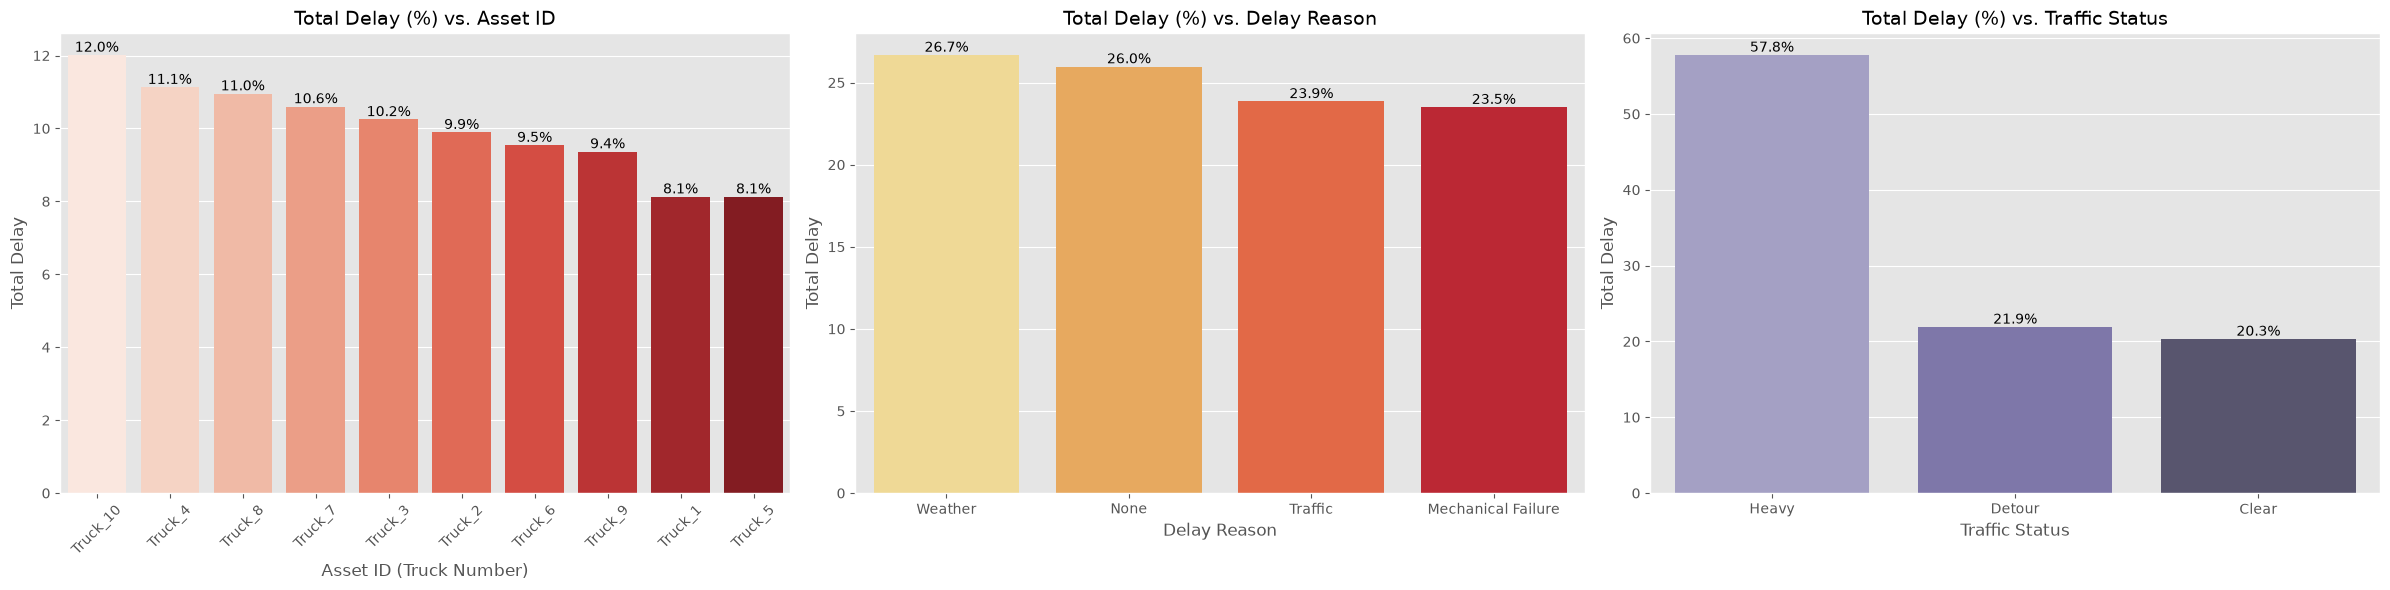

In [4]:
delay_df = df[df['Logistics_Delay'] == 1].copy()
#从原始数据表 df 中，筛选出“物流延迟”等于 1（即发生了延迟）的所有行，并将结果复制到一个新的表格 delay_df 中。
total_delay_shipments = len(delay_df)

#计算并排序延迟贡献的函数
def calculate_contribution(group_col, df_delay, total_delays):
    counts = df_delay.groupby(group_col).size().reset_index(name='Delay_Count')
    #size()计算数组中元素的数量reset_index（）重置索引。给计数值那一列命名为 'Delay_Count'
    counts['Percent_Contribution'] = (counts['Delay_Count'] / total_delays) * 100#计算各类百分比
    return counts.sort_values(by='Percent_Contribution', ascending=False)#按百分比降序排序并返回

delay_counts_asset = calculate_contribution('Asset_ID', delay_df, total_delay_shipments)# 资产
delay_counts_reason = calculate_contribution('Logistics_Delay_Reason', delay_df, total_delay_shipments)#物流延迟原因
delay_counts_status = calculate_contribution('Traffic_Status', delay_df, total_delay_shipments)#交通状态

#绘制全部三张图表

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
plt.style.use('ggplot')

# 1. Asset_ID
sns.barplot(
    x='Asset_ID',
    y='Percent_Contribution',
    data=delay_counts_asset,
    palette='Reds',#柱子的颜色方案
    ax=axes[0]#图形绘制在第一个子图
)

axes[0].set_title('Total Delay (%) vs. Asset ID', fontsize=14)
axes[0].set_xlabel('Asset ID (Truck Number)', fontsize=12)
axes[0].set_ylabel('Total Delay', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
#.tick_params(...) 用于调整刻度标签（即坐标轴上的文字）的外观。rotation=45 表示将刻度标签旋转 45 度。

for container in axes[0].containers:#.containers 是一个列表，里面存放着图中所有的“容器”对象
    axes[0].bar_label(container, fmt='%.1f%%')

# 2. Logistics_Delay_Reason
sns.barplot(
    x='Logistics_Delay_Reason',
    y='Percent_Contribution',
    data=delay_counts_reason,
    palette='YlOrRd',
    ax=axes[1]
)

axes[1].set_title('Total Delay (%) vs. Delay Reason', fontsize=14)
axes[1].set_xlabel('Delay Reason', fontsize=12)
axes[1].set_ylabel('Total Delay', fontsize=12)
axes[1].tick_params(axis='x')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%')

# 3. Traffic_Status
sns.barplot(
    x='Traffic_Status',
    y='Percent_Contribution',
    data=delay_counts_status,
    palette='Purples_d',
    ax=axes[2]
)

axes[2].set_title('Total Delay (%) vs. Traffic Status', fontsize=14)
axes[2].set_xlabel('Traffic Status', fontsize=12)
axes[2].set_ylabel('Total Delay', fontsize=12)
axes[2].tick_params(axis='x')

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

底图加载失败： The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
（geopandas 1.0 起已移除 datasets 接口，这里退化为空白画布）


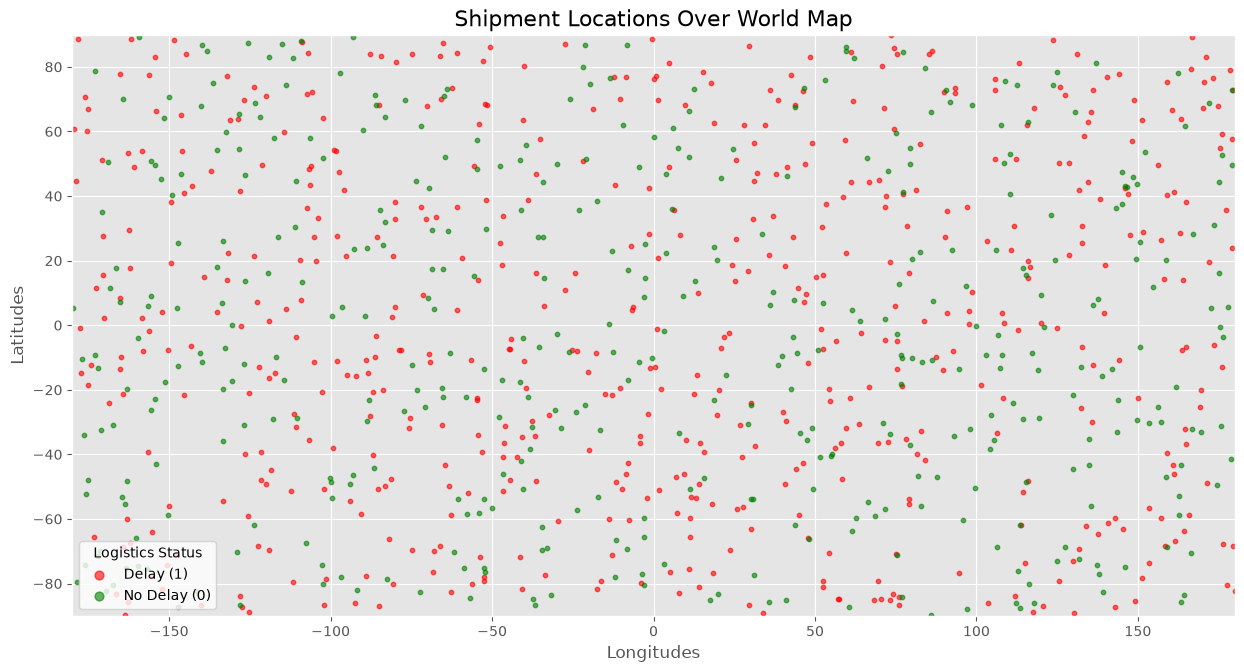

In [5]:
import geopandas#geopandas 是在数据分析中处理地理空间数据（比如地图、坐标、区域边界等）的常用工具。

# --- Prepare Data ---

# Separate the data into Delay (1) and No Delay (0) groups.
delayed = df[df['Logistics_Delay'] == 1]
no_delay = df[df['Logistics_Delay'] == 0]

# --- Load World Map Boundaries ---

try:
    world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))
    # 从 geopandas 自带的“地图库”里读取一张世界地图的存放位置
except Exception as e:#所有异常的基类保存到变量 e 中。
    print('底图加载失败：', e)
    print('（geopandas 1.0 起已移除 datasets 接口，这里退化为空白画布）')
    world = None

# --- Generate Static Map with Boundaries ---

fig, ax = plt.subplots(figsize=(15, 8))
plt.style.use('default')

#根据世界地图是否加载成功，来决定是否在地图上画底图，但无论成功与否，都会设置相同的坐标轴范围
if world is not None:

    # 设定世界地图的边界范围.
    world.plot(
        ax=ax,
        color='lightgrey',
        edgecolor='black',
        linewidth=0.125
    )

    # 根据世界地图设置绘图范围限制。
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

else:

    # 如果世界地图加载失败，则在空白画布上绘图。
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

# --- 叠加货运数据---

# 绘制延迟点（红色圆圈）.
ax.scatter(
    delayed['Longitude'],#X轴
    delayed['Latitude'],#Y轴
    color='red',
    s=10,#点的大小
    alpha=0.6,#点的透明度。
    label='Delay (1)'#图例标签
)

# 绘制无延迟点（绿色圆圈）.
ax.scatter(
    no_delay['Longitude'],
    no_delay['Latitude'],
    color='green',
    s=10,
    alpha=0.6,
    label='No Delay (0)'
)

# --- Plot Customization ---

ax.set_title('Shipment Locations Over World Map', fontsize=16)#fontsize设置字体大小
ax.set_xlabel('Longitudes', fontsize=12)
ax.set_ylabel('Latitudes', fontsize=12)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='lower left', title='Logistics Status', markerscale=2)
#loc='lower left'：图例放在图的左下角。
plt.show()

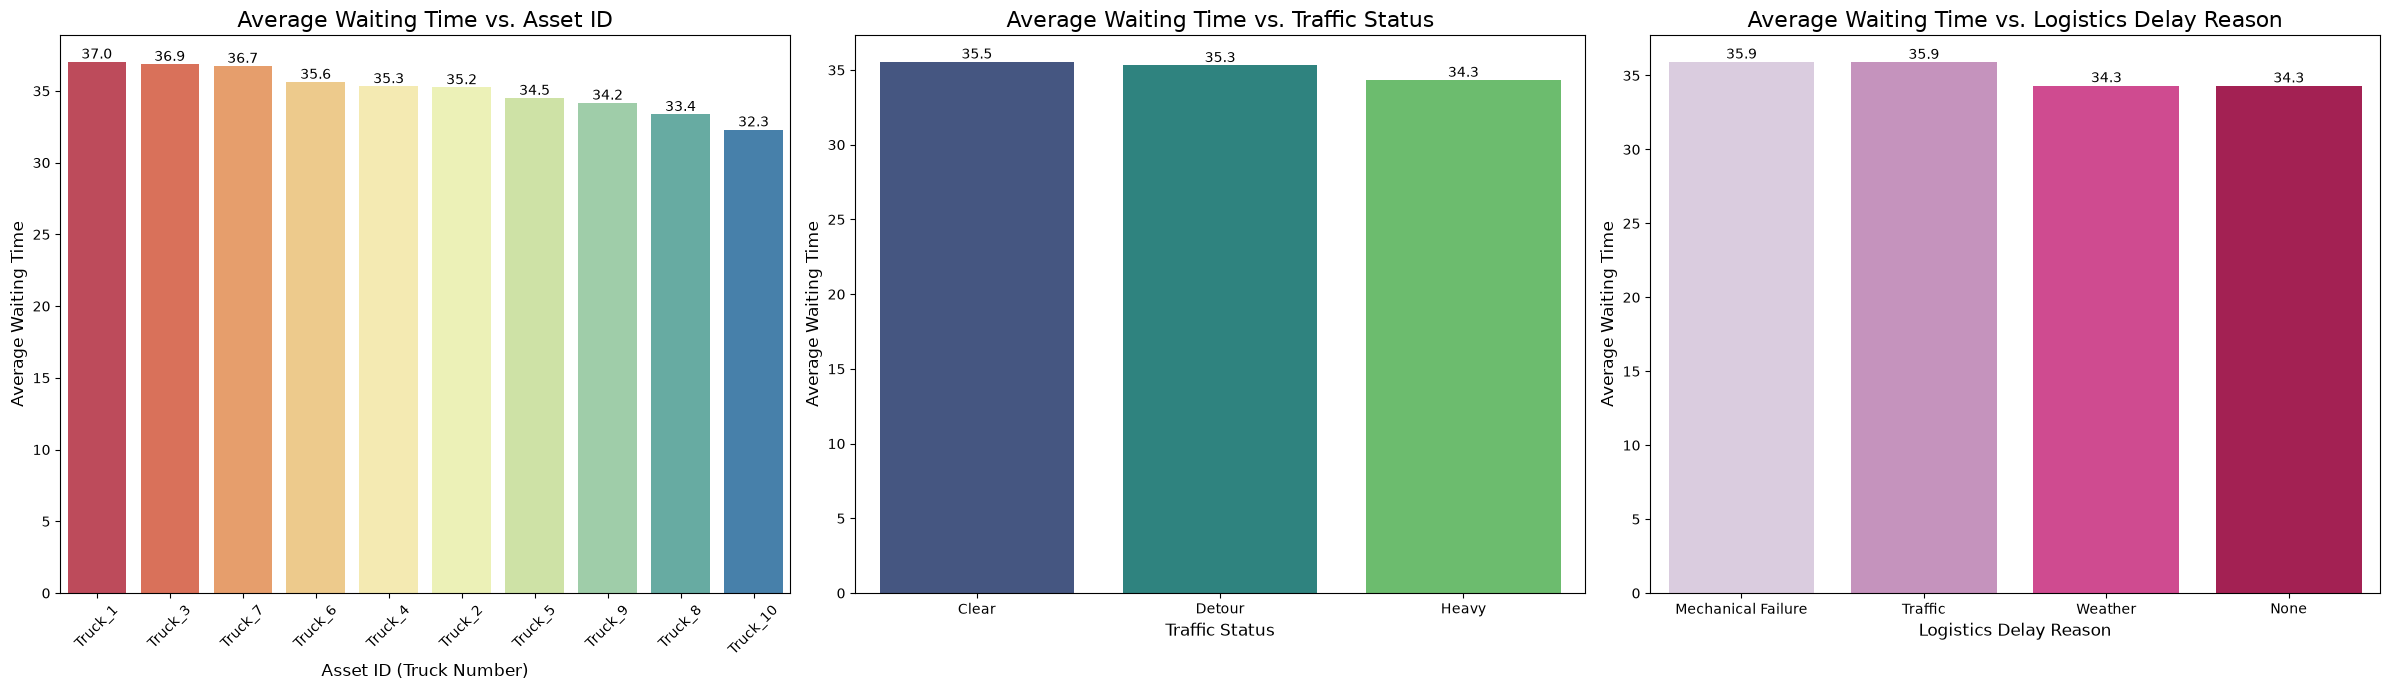

In [6]:
grouping_variables = [
    # (分组列名, x轴标签, 颜色调色板)
    ('Asset_ID', 'Asset ID (Truck Number)', 'Spectral'),
    ('Traffic_Status', 'Traffic Status', 'viridis'),
    ('Logistics_Delay_Reason', 'Logistics Delay Reason', 'PuRd')
]

# --- 计算和图表---

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
plt.style.use('ggplot')

for i, (group_col, x_label, palette) in enumerate(grouping_variables):

    # 计算平均等待时间.
    avg_waiting_time = df.groupby(group_col)['Waiting_Time'].mean().reset_index(name='Average_Waiting_Time_min')

    # 对数据进行排序.
    avg_waiting_time = avg_waiting_time.sort_values(
        by='Average_Waiting_Time_min', ascending=False
    )

    sns.barplot(
        x=group_col,
        y='Average_Waiting_Time_min',
        data=avg_waiting_time,
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(f'Average Waiting Time vs. {x_label}', fontsize=16)
    axes[i].set_xlabel(x_label, fontsize=12)
    axes[i].set_ylabel('Average Waiting Time', fontsize=12)

    # 为提升可读性和一致性进行特定图形调整
    if group_col == 'Asset_ID':
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_title(f'Average Waiting Time vs. Asset ID', fontsize=16)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

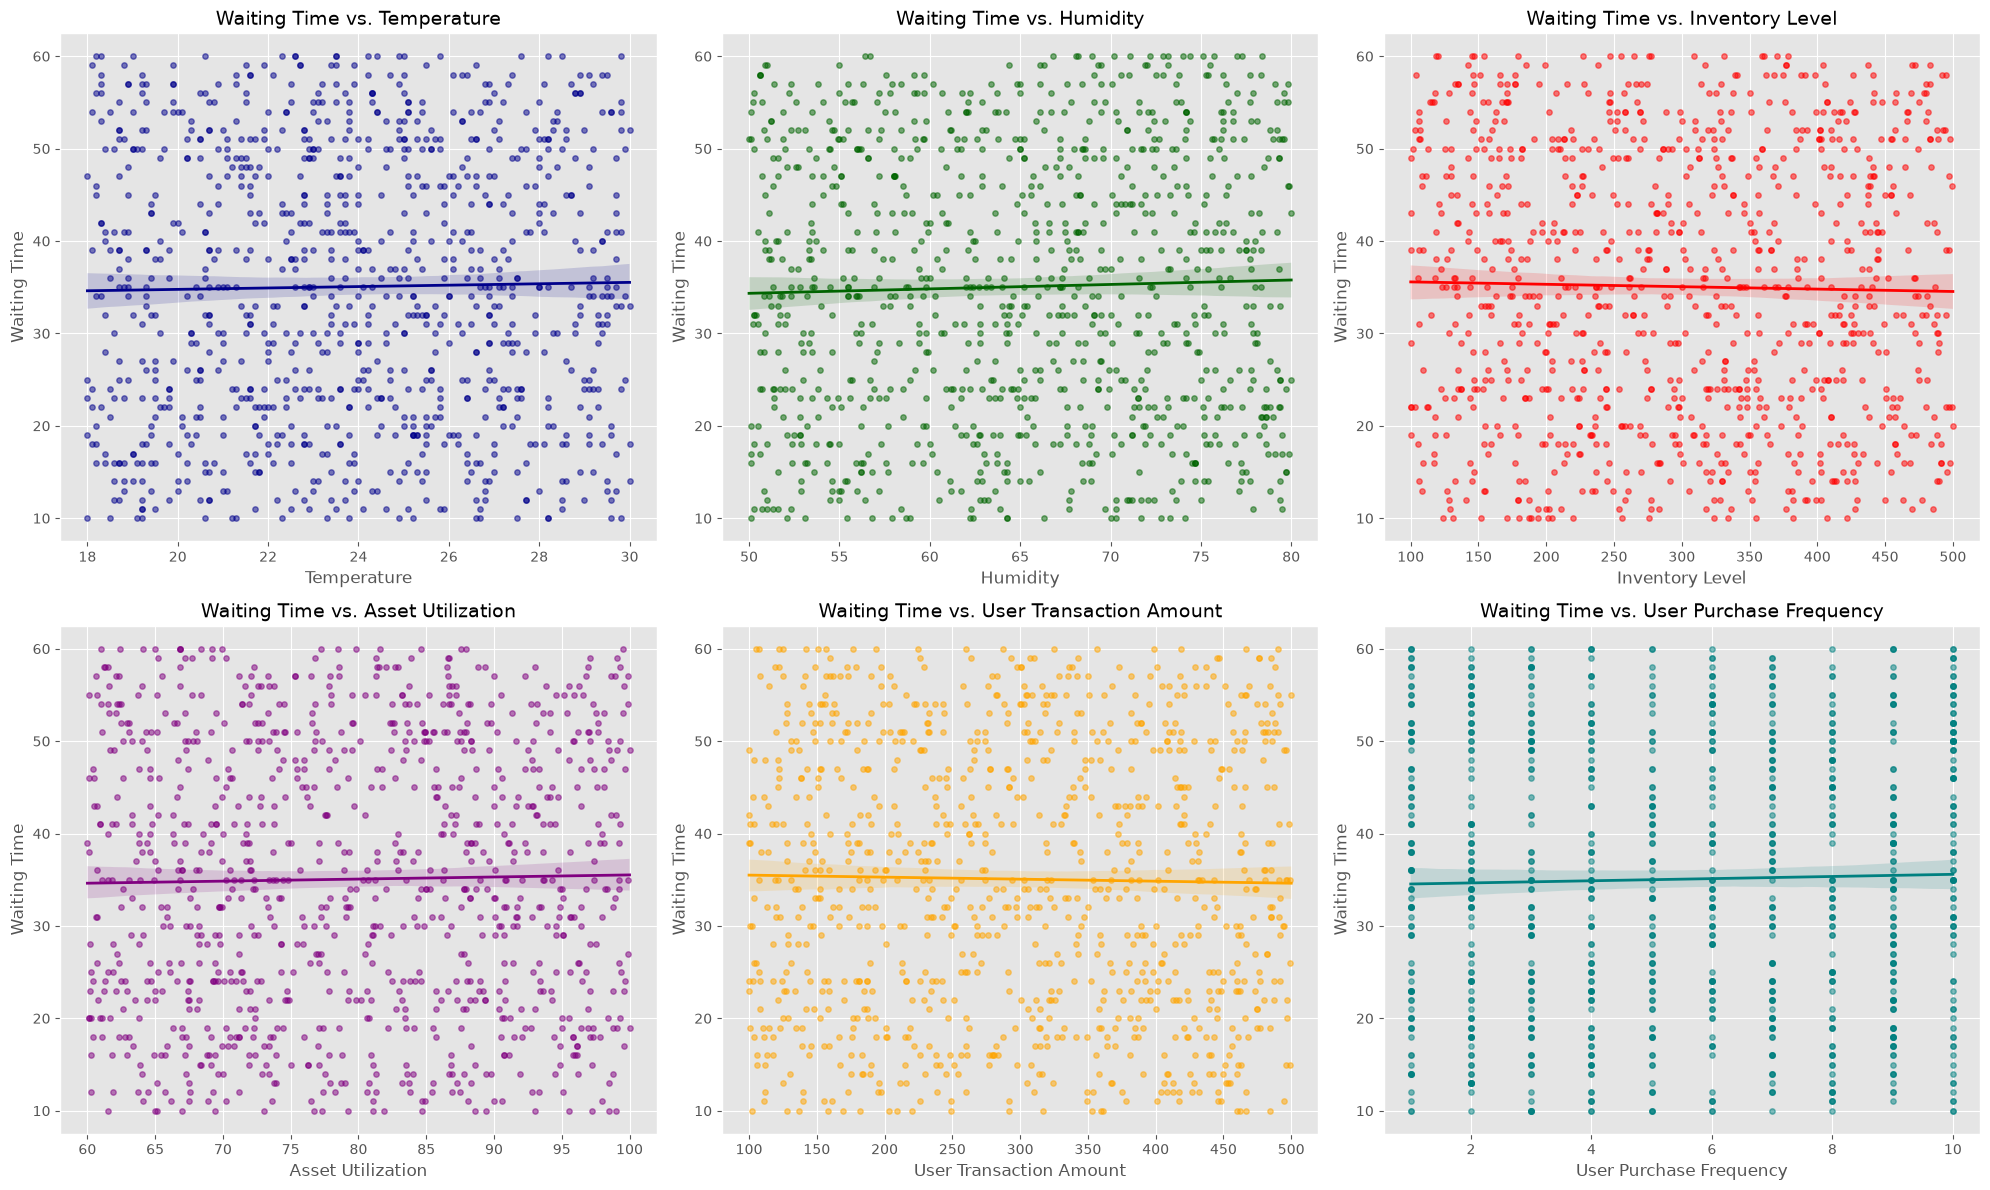

In [7]:
dependent_variable = 'Waiting_Time'
independent_variables = [
    'Temperature',
    'Humidity',
    'Inventory_Level',
    'Asset_Utilization',
    'User_Transaction_Amount',
    'User_Purchase_Frequency'
]

# Distinct colors for the six plots.
colors = [
    'darkblue', 'darkgreen', 'red',
    'purple', 'orange', 'teal'
]

# --- Generate Linear Graphs with Trendlines ---

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.style.use('ggplot')

# Flatten the axes array for easy iteration.
axes = axes.flatten()

for i, x_var in enumerate(independent_variables):

    color = colors[i]

    sns.regplot(
        x=x_var,
        y=dependent_variable,
        data=df,
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 's': 15, 'color': color},
        line_kws={'color':color, 'lw': 2}
    )

    title_label = x_var.replace('_', ' ')
    axes[i].set_title(f'Waiting Time vs. {title_label}', fontsize=14)
    axes[i].set_xlabel(title_label, fontsize=12)
    axes[i].set_ylabel('Waiting Time', fontsize=12)

plt.tight_layout()
plt.show()

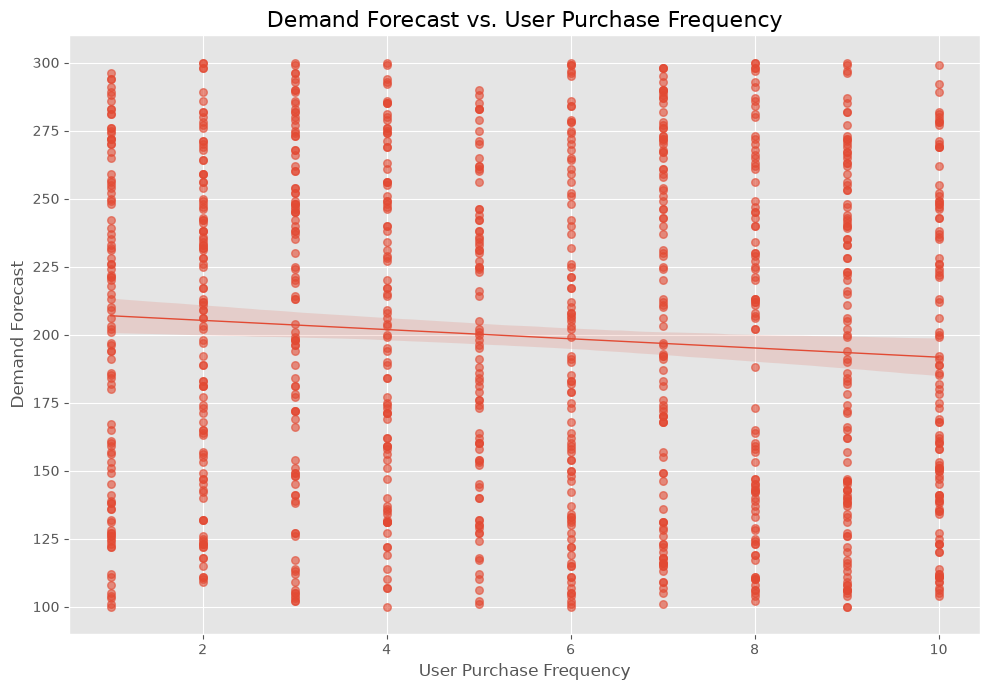

In [8]:
plt.figure(figsize=(10, 7))
plt.style.use('ggplot')

sns.regplot(
    x='User_Purchase_Frequency',
    y='Demand_Forecast',
    data=df,
    scatter_kws={'alpha': 0.6, 's': 30,},
    line_kws={'lw': 1}
)

plt.title('Demand Forecast vs. User Purchase Frequency', fontsize=16)
plt.xlabel('User Purchase Frequency', fontsize=12)
plt.ylabel('Demand Forecast', fontsize=12)

plt.tight_layout()
plt.show()

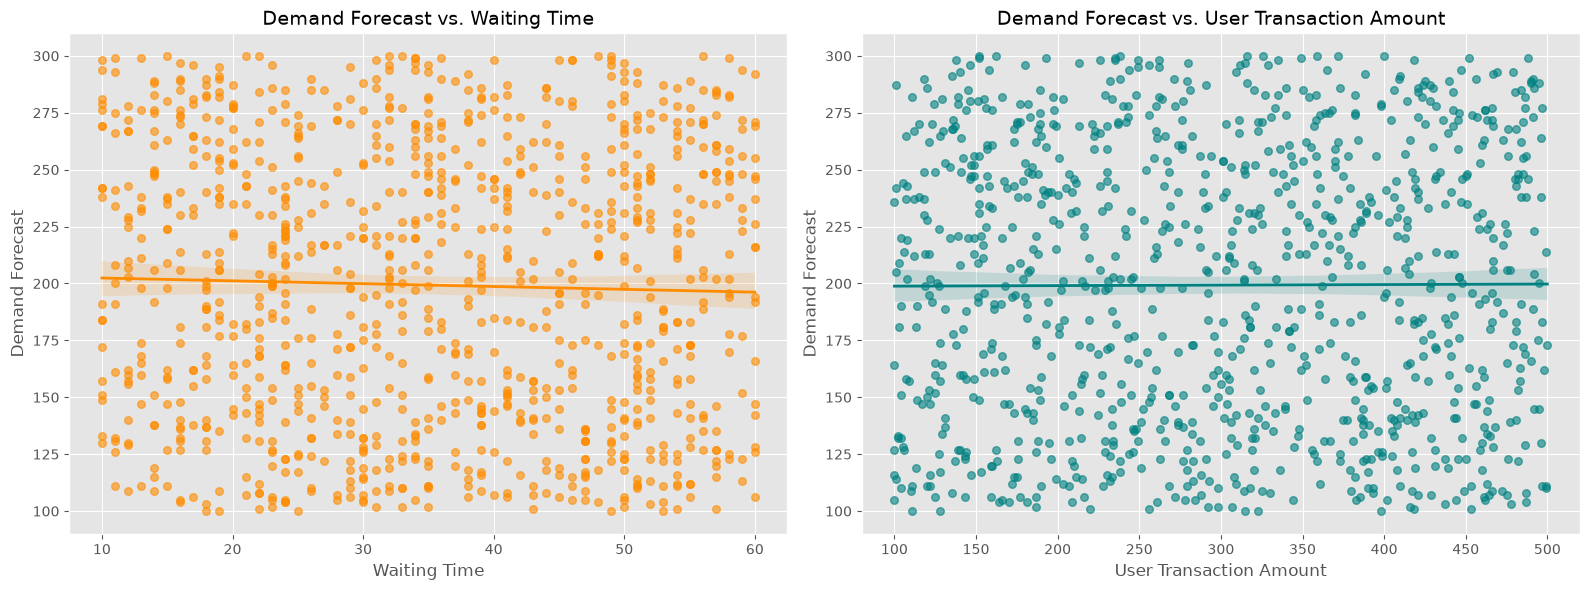

In [9]:
dependent_variable = 'Demand_Forecast'
independent_variables = [
    ('Waiting_Time', 'darkorange'),
    ('User_Transaction_Amount', 'teal')
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.style.use('ggplot')

for i, (x_var, color) in enumerate(independent_variables):

    sns.regplot(
        x=x_var,
        y=dependent_variable,
        data=df,
        ax=axes[i],
        scatter_kws={'alpha':0.6, 's':30, 'color':color},
        line_kws={'color':color, 'lw':2}
    )

    title_label = x_var.replace('_', ' ')
    axes[i].set_title(f'Demand Forecast vs. {title_label}', fontsize=14)
    axes[i].set_xlabel(title_label, fontsize=12)
    axes[i].set_ylabel(dependent_variable.replace('_', ' '), fontsize=12)

plt.tight_layout()
plt.show()

## 证据一：均匀随机性检验

均匀分布的标准差有公式：`(上限 - 下限) / sqrt(12)`。
如果某个数值字段的实际标准差贴着这个理论值，它大概率是随机生成的。


In [10]:
# =====================================================================
# 证据一：均匀随机性检验
#
# 原理：均匀分布的标准差有公式 —— (上限 - 下限) / sqrt(12)。
#      实际标准差若贴着这个理论值，说明数据是随机生成的。
# =====================================================================


# 检测函数来自可复用工具；工具里还有 detect_target_leakage /
# check_label_consistency / check_extreme_ratio / class_balance
from src.audit import test_uniformity
# 若想让它自动推断区间（不必手写 RANGES），可用：
#     from src.audit import default_numeric_ranges


RANGES = {
    'Latitude': (-90, 90), 'Longitude': (-180, 180),
    'Temperature': (18, 30), 'Humidity': (50, 80),
    'Inventory_Level': (100, 500), 'Asset_Utilization': (60, 100),
    'User_Transaction_Amount': (100, 500), 'Demand_Forecast': (100, 300),
    'Waiting_Time': (10, 60),
}

rows = []
for col, (lo, hi) in RANGES.items():
    rows.append({'field': col, 'range': f'[{lo}, {hi}]',
                 **test_uniformity(df[col], lo, hi)})

uniformity = pd.DataFrame(rows)
print(uniformity.to_string(index=False))
print()
print(f"{int(uniformity['is_uniform'].sum())}/{len(uniformity)} "
      f"个数值字段通过均匀随机性检验。")


                  field       range    n    low  high  actual_sd  theoretical_sd  ratio  is_uniform
               Latitude   [-90, 90] 1000  -90.0  90.0    51.9972         51.9615 1.0007        True
              Longitude [-180, 180] 1000 -180.0 180.0   104.8436        103.9230 1.0089        True
            Temperature    [18, 30] 1000   18.0  30.0     3.3222          3.4641 0.9590        True
               Humidity    [50, 80] 1000   50.0  80.0     8.7538          8.6603 1.0108        True
        Inventory_Level  [100, 500] 1000  100.0 500.0   113.5548        115.4701 0.9834        True
      Asset_Utilization   [60, 100] 1000   60.0 100.0    11.6312         11.5470 1.0073        True
User_Transaction_Amount  [100, 500] 1000  100.0 500.0   117.7878        115.4701 1.0201        True
        Demand_Forecast  [100, 300] 1000  100.0 300.0    59.9208         57.7350 1.0379        True
           Waiting_Time    [10, 60] 1000   10.0  60.0    14.4778         14.4338 1.0030        True


## 证据二：取值范围是否"过于整齐"

真实业务数据的取值范围几乎不会是一串圆整数；而 `random.uniform(下限, 上限)`
生成的数据，区间就是漂亮的整数区间。


                            min     max   width  looks_round
Latitude                 -89.79   89.87  179.66        False
Longitude               -179.82  179.92  359.74        False
Temperature               18.00   30.00   12.00        False
Humidity                  50.00   80.00   30.00         True
Inventory_Level          100.00  500.00  400.00         True
Asset_Utilization         60.00  100.00   40.00         True
User_Transaction_Amount  100.00  500.00  400.00         True
Demand_Forecast          100.00  300.00  200.00         True
Waiting_Time              10.00   60.00   50.00         True

6/9 个字段的取值区间宽度正好是 10 的整数倍。


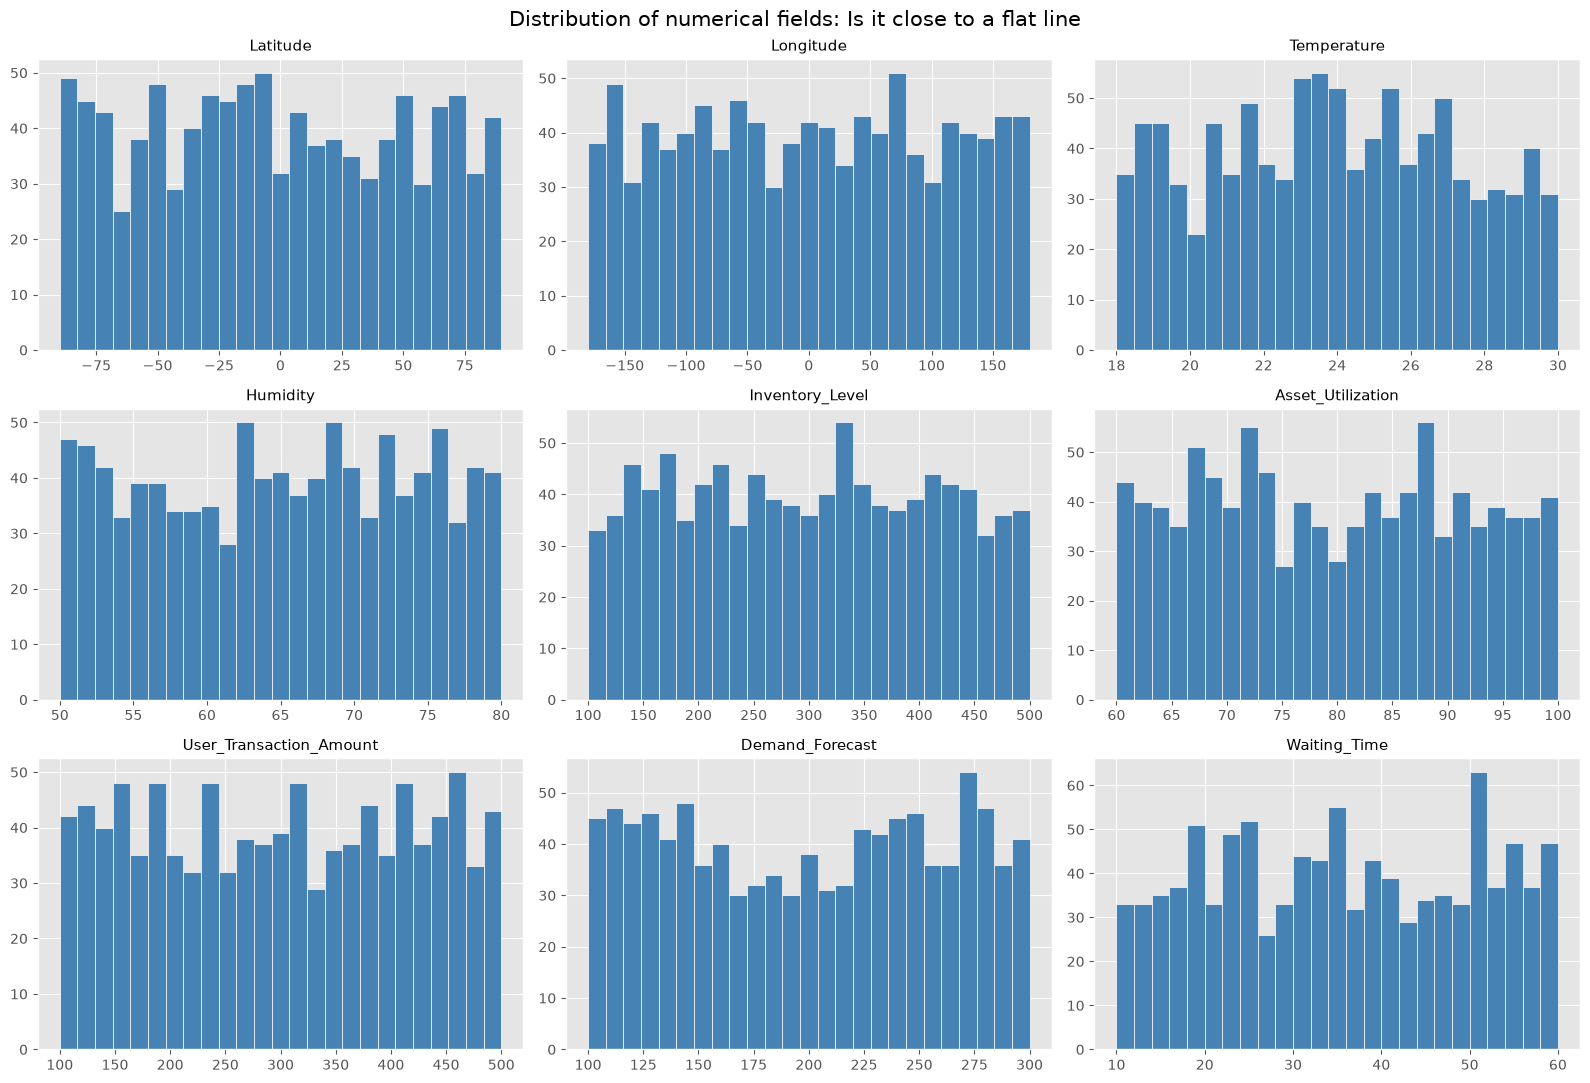

In [11]:
# =====================================================================
# 证据二：取值范围是否"过于整齐"
#
# 真实业务数据的取值范围几乎不会是一串圆整数；用
# random.uniform(下限, 上限) 生成时，区间就是漂亮的整数区间。
# =====================================================================

observed = pd.DataFrame({
    'min': df[list(RANGES)].min(),
    'max': df[list(RANGES)].max(),
}).round(2)
observed['width'] = observed['max'] - observed['min']
observed['looks_round'] = observed['width'].apply(
    lambda w: w == int(w) and int(w) % 10 == 0)

print(observed.to_string())
print()
print(f"{int(observed['looks_round'].sum())}/{len(observed)} "
      f"个字段的取值区间宽度正好是 10 的整数倍。")

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flatten(), RANGES):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=11)
plt.suptitle('Distribution of numerical fields: Is it close to a flat line', fontsize=15)#数值字段的分布：是否接近一条平线
plt.tight_layout()
plt.show()


## 证据三：`Logistics_Delay_Reason` 是否为随机标签

如果这个字段真是"延迟原因"，它至少应当与"是否延迟"相关。


In [12]:
# =====================================================================
# 证据三：Logistics_Delay_Reason 是否为随机标签
#
# 若该字段真是"延迟原因"，它至少应当与"是否延迟"相关。
# =====================================================================

from scipy.stats import chi2_contingency

reason = df['Logistics_Delay_Reason']
delay = df['Logistics_Delay'].astype(int)

ct = pd.crosstab(reason, delay)
print('Logistics_Delay_Reason × Logistics_Delay：')
print(ct)
print()

chi2, p, dof, expected = chi2_contingency(ct.values)
print(f'卡方统计量 = {chi2:.4f}   自由度 = {dof}   p 值 = {p:.4f}')
print(f'判断阈值 p < 0.05 -> {"显著" if p < 0.05 else "不显著"}')
print()

rate = (df.groupby('Logistics_Delay_Reason', observed=True)['Logistics_Delay']
          .apply(lambda s: s.astype(int).mean()))
print('各"原因"的延迟率（若字段有信息，各组应当明显不同）：')
print((rate * 100).round(2).to_string())
print()
print(f'四组都紧贴总体延迟率 {delay.mean():.2%}，最大差距不到 1 个百分点。')

named = reason.isin(['Weather', 'Traffic', 'Mechanical Failure'])
a = int((named & (delay == 0)).sum())
b = int(((reason == 'None') & (delay == 1)).sum())
print()
print('另一处矛盾：')
print(f'  填了具体原因却标记为"未延迟"：{a} 行')
print(f'  标记为延迟但原因是 None     ：{b} 行')
print(f'  合计 {a + b} 行，占全表 {100 * (a + b) / len(df):.1f}%')


Logistics_Delay_Reason × Logistics_Delay：
Logistics_Delay           0    1
Logistics_Delay_Reason          
Mechanical Failure      101  133
None                    116  147
Traffic                 101  135
Weather                 116  151

卡方统计量 = 0.0940   自由度 = 3   p 值 = 0.9925
判断阈值 p < 0.05 -> 不显著

各"原因"的延迟率（若字段有信息，各组应当明显不同）：
Logistics_Delay_Reason
Mechanical Failure    56.84
None                  55.89
Traffic               57.20
Weather               56.55

四组都紧贴总体延迟率 56.60%，最大差距不到 1 个百分点。

另一处矛盾：
  填了具体原因却标记为"未延迟"：318 行
  标记为延迟但原因是 None     ：147 行
  合计 465 行，占全表 46.5%


In [13]:
# =====================================================================
# 结论：这份数据是不是合成的？
# =====================================================================

named = df['Logistics_Delay_Reason'].isin(['Weather', 'Traffic', 'Mechanical Failure'])
delay = df['Logistics_Delay'].astype(int)
contradiction = (int((named & (delay == 0)).sum())
                 + int(((df['Logistics_Delay_Reason'] == 'None') & (delay == 1)).sum()))

print('证据汇总')
print('-' * 62)
print(f"1. 均匀随机性：{int(uniformity['is_uniform'].sum())}/{len(uniformity)} "
      f"个数值字段的标准差与均匀分布理论值偏差在 ±10% 内")
print(f"2. 取值范围  ：{int(observed['looks_round'].sum())}/{len(observed)} "
      f"个字段的区间宽度正好是 10 的整数倍")
print(f"3. 原因字段  ：与是否延迟独立（卡方 p = {p:.4f}），四组延迟率几乎相同")
print(f"4. 内部矛盾  ：{contradiction} 行（{100 * contradiction / len(df):.1f}%）"
      f"存在逻辑矛盾")
print('-' * 62)
print()
print('结论：四项证据一致指向同一判断 ——')
print('      这份数据是在各自区间内均匀随机生成、再按规则拼装的合成数据，')
print('      其中不存在真实世界的业务规律。')
print()
print('因此它适合练习分析方法、识别数据陷阱，')
print('但不适合产出业务结论或建立预测模型。')


证据汇总
--------------------------------------------------------------
1. 均匀随机性：9/9 个数值字段的标准差与均匀分布理论值偏差在 ±10% 内
2. 取值范围  ：6/9 个字段的区间宽度正好是 10 的整数倍
3. 原因字段  ：与是否延迟独立（卡方 p = 0.9925），四组延迟率几乎相同
4. 内部矛盾  ：465 行（46.5%）存在逻辑矛盾
--------------------------------------------------------------

结论：四项证据一致指向同一判断 ——
      这份数据是在各自区间内均匀随机生成、再按规则拼装的合成数据，
      其中不存在真实世界的业务规律。

因此它适合练习分析方法、识别数据陷阱，
但不适合产出业务结论或建立预测模型。


## 实验印证：这份数据能不能用来建模？

前面三条证据说明数据是合成/随机生成的。那它到底能不能建预测模型？
用交叉验证直接量一下 —— 三个对照组：

| 实验 | 特征 | 预期 |
|---|---|---|
| A | 用上泄漏字段（`Shipment_Status` / `Traffic_Status`） | 准确率虚高 ≈ 100% |
| B | 删掉泄漏字段，只用其余合法特征 | 应回落到多数类基线附近 |
| C | 多数类基线（永远猜"延迟"） | 模型必须超过的下限 |

**判据**：若 B 不明显高于 C，说明去掉泄漏后数据里没有可学习的信号。


In [14]:
# =====================================================================
# 基线模型实验：这份数据能不能建模？
#
# 三个对照组：
#   A 用上泄漏字段 —— 模型学到的是恒等关系，准确率虚高
#   B 删掉泄漏字段 —— 只用 7 个合法特征
#   C 多数类基线   —— 永远猜"延迟"，任何模型的下限
# =====================================================================

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

TARGET = 'Logistics_Delay'
y = df[TARGET].astype(int)

# 分层 5 折 + 固定随机种子，保证结果可复现
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LEAKY_COLS = ['Shipment_Status', 'Traffic_Status']
SAFE_COLS = ['Temperature', 'Humidity', 'Inventory_Level', 'Asset_Utilization',
             'User_Transaction_Amount', 'User_Purchase_Frequency', 'Demand_Forecast']
# 排除说明：前两个是泄漏源；Logistics_Delay_Reason 与目标独立（见 notebooks/03 的检测三）。


def prepare(cols):
    """分类列做 one-hot，数值列原样保留。"""
    X = df[cols].copy()
    cat = [c for c in X.columns
           if X[c].dtype == object or str(X[c].dtype).startswith('str')]
    if cat:
        X = pd.get_dummies(X, columns=cat)
    return X.astype(float)


def score(model, cols):
    return cross_val_score(model, prepare(cols), y, cv=CV, scoring='accuracy')


rows = []
for label, cols in (('A 用泄漏字段', LEAKY_COLS), ('B 删掉泄漏字段', SAFE_COLS)):
    s = score(RandomForestClassifier(n_estimators=200, random_state=42), cols)
    rows.append((label, len(cols), s.mean(), s.std()))
s = score(DummyClassifier(strategy='most_frequent'), SAFE_COLS)
rows.append(('C 多数类基线', len(SAFE_COLS), s.mean(), s.std()))

print('=' * 62)
print(f'{"实验":20s} {"特征数":>6s} {"准确率":>10s} {"标准差":>9s}')
print('-' * 62)
for label, k, m, sd in rows:
    print(f'{label:20s} {k:>6d} {m:>10.4f} {sd:>9.4f}')
print('=' * 62)

acc_a, acc_b, acc_c = rows[0][2], rows[1][2], rows[2][2]
diff = acc_b - acc_c
print()
print(f'A（用泄漏字段）{acc_a:.2%} —— 几乎完美，但这是"答案写在特征里"，不是模型厉害。')
print(f'B（删掉泄漏字段）{acc_b:.2%} vs C（多数类基线）{acc_c:.2%}，差 {diff:+.2%}。')
print()
if diff <= 0.02:
    print(f'结论：去掉泄漏字段后，模型没有学到任何有效信号（相对基线 {diff:+.2%}）。')
    if diff < 0:
        print('      B 甚至低于"永远猜多数类"——这是随机噪声的典型表现：')
        print('      模型只能在噪声上过拟合，还不如不学。')
    print('      因此这份数据不能用于建立预测模型，')
    print('      任何高准确率都来自泄漏，而不是真实规律。')
else:
    print(f'结论：B 明显高于 C（{diff:+.2%}），剩余特征里仍有一些信号，可进一步分析。')


实验                      特征数        准确率       标准差
--------------------------------------------------------------
A 用泄漏字段                   2     1.0000    0.0000
B 删掉泄漏字段                  7     0.5290    0.0191
C 多数类基线                   7     0.5660    0.0020

A（用泄漏字段）100.00% —— 几乎完美，但这是"答案写在特征里"，不是模型厉害。
B（删掉泄漏字段）52.90% vs C（多数类基线）56.60%，差 -3.70%。

结论：去掉泄漏字段后，模型没有学到任何有效信号（相对基线 -3.70%）。
      B 甚至低于"永远猜多数类"——这是随机噪声的典型表现：
      模型只能在噪声上过拟合，还不如不学。
      因此这份数据不能用于建立预测模型，
      任何高准确率都来自泄漏，而不是真实规律。
